# Block C, Year 1: Deep Learning Notebook

**Name**: Farazică Ana-Maria

## Task 3.1: Create an Image Dataset

### A: Dataset Creation

I structured my dataset into five distinct classes: `Fully Stop`, `Priority Road`, `Priority Over Oncoming Traffic`, `Give Way`, and `Give Way to Oncoming Traffic`.

To gather the images, I used a combination of manual collection and publicly available datasets. Approximately 90% of the images were manually collected through Mapillary and Google Street View. I utilized Mapillary’s map function to pinpoint locations of specific traffic signs. Then, using Google Street View, I took screenshots of the relevant traffic signs.

- Mapillary: https://www.mapillary.com/app/

- Google Street View: https://www.google.com/maps

For the remaining 10% of my dataset, I selectively gathered images from open and public datasets available online. Notable sources include:

- Traffic and Road Signs Computer Vision Project by Usman Chaudhry on RoboFlow: https://universe.roboflow.com/usmanchaudhry622-gmail-com/traffic-and-road-signs
- Stop Sign Detection 1 by YOLO on RoboFlow: https://universe.roboflow.com/yolo-ifyjn/stop-sign-detection-1
- Traffic Signs Detection Europe by Radu Oprea on RoboFlow: https://universe.roboflow.com/radu-oprea-r4xnm/traffic-signs-detection-europe
- Polish Traffic Signs Dataset by ChrisKJM on Kaggle: https://www.kaggle.com/datasets/chriskjm/polish-traffic-signs-dataset/data
- Additionally, I used the Road Signs Dataset from MakeML: https://makeml.app/datasets/road-signs

The final dataset contains a total of 702 images that captures all of the five approached classes.

### B: Dataset Cleaning

For the cleaning process, I adopted a manual approach to ensure the dataset was organized, consistent, and suitable for training, since I am working with a relatively small dataset. The first step involved reviewing all the images to confirm they were placed in the correct folders according to their respective classes. I carefully checked each image to ensure none had been misplaced or incorrectly labeled, maintaining a high level of accuracy from the beginning. Additionally, I checked for any duplicate images to prevent redundancy from affecting the dataset or the model’s performance, removing any repeats that might have been unintentionally included.

Next, I encountered the issue of inconsistent image formats. The images I had manually gathered were saved in `.jpg` format, while those sourced from other datasets were in `.png`. To maintain consistency across the entire dataset, I converted all images to `.jpg`. This ensured uniformity in file type, preventing potential issues during processing or model training.

After standardizing the image format, I focused on enhancing the quality of the images for better recognition. I cropped several pictures to zoom in on the traffic signs themselves, removing unnecessary parts of the environment, such as surrounding roads, vehicles, or pedestrians. This step helped make the signs more prominent and relevant for the image recognition system, ensuring the model focused on the key feature—the sign—rather than irrelevant background elements.

Finally, to ensure the dataset remained neat and easily navigable, I renamed the images systematically. This step helped organize the images with clear, descriptive filenames, making it easier to track and retrieve specific images during model training and testing. By carefully cleaning and organizing the dataset, I set a solid foundation for the image recognition system, ensuring optimal and efficient performance.

### C: Final Dataset

-For request only-

### D: Load and Split

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
from keras.layers import BatchNormalization
from tensorflow.keras.metrics import Precision, Recall, AUC, TopKCategoricalAccuracy

In [2]:
# Define early stopping callback
early_stopping = EarlyStopping(patience=4, restore_best_weights=True)

In [ ]:
dataset_path = ".../Deliverables/Dataset"

# Load the dataset 
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),  
    batch_size=32  
)

# Print class names 
print(dataset.class_names)

# Check the first batch of images and labels
for images, labels in dataset.take(1):
    print(images.shape, labels.shape)

Found 702 files belonging to 5 classes.
['Full Stop', 'Give Way', 'Give Way for oncoming traffic', 'Priority Over Oncoming Traffic', 'Priority Road']
(32, 128, 128, 3) (32,)


In [4]:
# Extract images and labels from the dataset
X = []
y = []
for images, labels in dataset:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X)
y = np.array(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=1/10,
                                                    random_state = 42)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 42)
                                                    
print(X_train.shape, X_val.shape, X_test.shape)


(560, 128, 128, 3) (71, 128, 128, 3) (71, 128, 128, 3)


## Task 3.2: Calculate Baselines

### A: Random Guess Accuracy

I first begin by I've calculating the probability of each traffic sign as in an balanced/normal distributed scenario, by dividing 100 to the number of classes (100/5, since I have 5 classes), which resulted in 20% probability for each class. Then I've calculated the guessing probability of each class according to its distribution in the dataset. The way I did that was by dividing the number of images in each class by 702(the total number of images in the dataset) and then multiply it by 100 to receive the percentage. The result for that was:
- Guessing Stop Signs: 29%
- Guessing Give Way: 24%
- Guessing Give Way to Oncoming Traffic: 15%
- Guessing Priority Road: 17%
- Guessing Priority Over Oncoming Traffic: 15%

After that I've calculated the accuracy for each class, which resulted as it follows:
- Accuracy Stop Signs: 5.8%
- Accuracy Give Way: 4.8%
- Accuracy Give Way to Oncoming Traffic: 3%
- Accuracy Priority Road: 3.4%
- Accuracy Priority Over Oncoming Traffic: 3%

As the last step, I've calculated the Total Random Guess Accuracy by adding up all of the accuracy results I've calculated above, which summarize to a value of 20%.

### B: Basic Multilayer Perceptron Accuracy

#### I: Preprocessing

In [5]:
# The preprocessing part of this project has already been done in a previous step by resizing the images to 128x128 pixels.
# You can see how I've done this in section 3.1-D

#### II: MLP Architecture 

In this code, I define a Multi-Layer Perceptron (MLP) model using the Keras library for a multi-class classification task. The function `create_mlp_model()` takes two arguments: `input_shape`, which represents the shape of the input images (128x128 pixels with 3 color channels in this case), and `num_classes`, which is the number of classes for classification (5 classes in this example).

The model is built using a sequential architecture. The first layer, `Flatten`, reshapes the input image from a 3D array (128x128x3) into a 1D vector, which is necessary for feeding the data into fully connected layers. After that, I add three dense layers with ReLU activation. The number of neurons in these layers is progressively reduced from 512 to 256, and then to 128, which allows the model to learn increasingly abstract representations of the input data.

The final layer is a `Dense` layer, where the number of neurons is equal to `num_classes` (5 in this case), and I use the softmax activation function. Softmax is ideal for multi-class classification because it outputs probabilities for each class, with the sum of all probabilities equal to 1.

Finally, the function returns the compiled model, which I can then train. I use `model.summary()` to display the architecture of the model.

In [6]:
def create_mlp_model(input_shape, num_classes):
    model = models.Sequential()

    # Flatten the input image
    model.add(layers.Flatten(input_shape=input_shape))

    # Add a few dense layers
    model.add(layers.Dense(512, activation='relu')) 
    model.add(layers.Dense(256, activation='relu'))  
    model.add(layers.Dense(128, activation='relu'))  

    # Output layer with softmax activation for multi-class classification
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Example usage
input_shape = (128, 128, 3) 
num_classes = 5  

# Create the model
model = create_mlp_model(input_shape, num_classes)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 49152)             0         
                                                                 
 dense (Dense)               (None, 512)               25166336  
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 5)                 645       
                                                                 
Total params: 25,331,205
Trainable params: 25,331,205
Non-trainable params: 0
_________________________________________________________________


#### III: MLP Training

I compile the model using the Adam optimizer with a learning rate of 0.001. The loss function used is sparse categorical cross-entropy, suitable for multi-class classification tasks. I also include accuracy as a metric to track performance during training.

Then, I train the model with the `fit()` method, passing in the training data (`X_train`, `y_train`) and validation data (`X_val`, `y_val`). The model will run for 50 epochs with a batch size of 32, and I use an early stopping callback to prevent overfitting by stopping training when performance no longer improves.

In [7]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stopping])

Epoch 1/50
18/18 [==============================] - 2s 78ms/step - loss: 5455.9224 - accuracy: 0.2018 - val_loss: 1341.1763 - val_accuracy: 0.3239
Epoch 2/50
18/18 [==============================] - 1s 66ms/step - loss: 1330.7836 - accuracy: 0.2714 - val_loss: 1041.4543 - val_accuracy: 0.2113
Epoch 3/50
18/18 [==============================] - 1s 64ms/step - loss: 488.8551 - accuracy: 0.3696 - val_loss: 951.6115 - val_accuracy: 0.3099
Epoch 4/50
18/18 [==============================] - 1s 64ms/step - loss: 307.1777 - accuracy: 0.5071 - val_loss: 138.7263 - val_accuracy: 0.4930
Epoch 5/50
18/18 [==============================] - 1s 62ms/step - loss: 90.8535 - accuracy: 0.6286 - val_loss: 146.4683 - val_accuracy: 0.5352
Epoch 6/50
18/18 [==============================] - 1s 62ms/step - loss: 97.0552 - accuracy: 0.5946 - val_loss: 154.9919 - val_accuracy: 0.4789
Epoch 7/50
18/18 [==============================] - 1s 62ms/step - loss: 48.6484 - accuracy: 0.7321 - val_loss: 176.6279 - val_a

#### IV: MLP Evaluation

This code evaluates the model’s performance on the test set (X_test, y_test). The evaluate() function returns the loss and accuracy of the model on the test data.

In [8]:
# Evaluate the model
model.evaluate(X_test, y_test)

3/3 [==============================] - 0s 11ms/step - loss: 63.7300 - accuracy: 0.6901


[63.73002243041992, 0.6901408433914185]

The evaluation results indicate that the model's performance on the test set is mixed. The high loss value (over 50) suggests that the model's predictions are far from the true labels, which could be due to issues like overfitting, inadequate generalization, or a mismatch between the training and test data distributions.

However, the accuracy of 65-75% indicates that the model is still able to correctly classify a significant portion of the test samples. While this isn't perfect, it shows that the model has learned useful patterns, but there's potential for improvement—perhaps through further tuning, better data, or different model architectures to reduce the high loss and increase the accuracy.

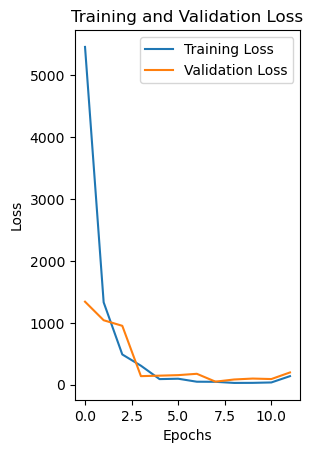

In [9]:
# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

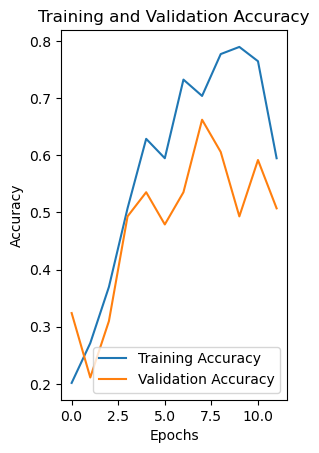

In [10]:
# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

Confusion Matrix

3/3 [==============================] - 0s 8ms/step


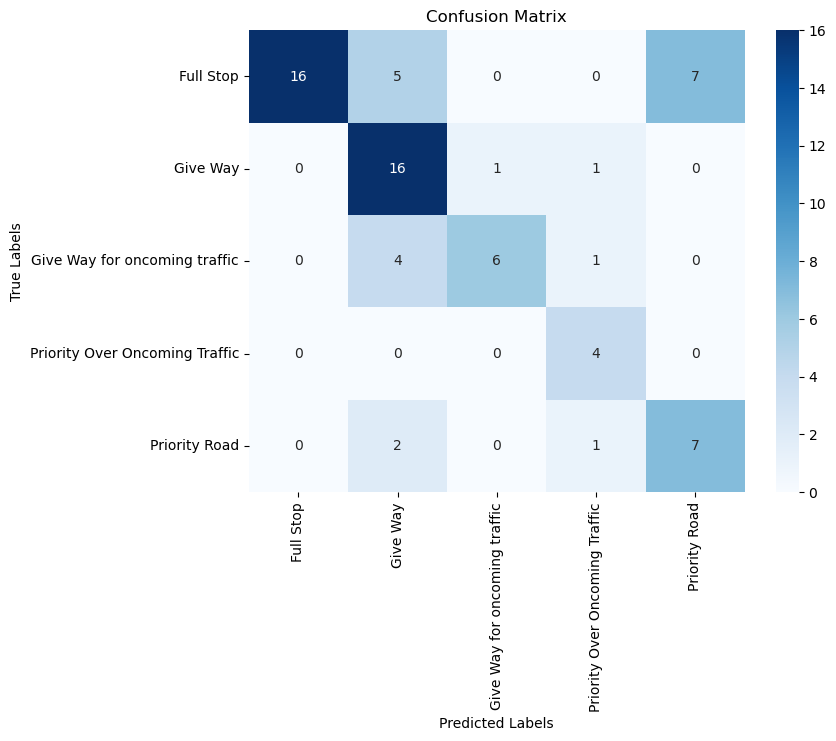

In [11]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_names, yticklabels=dataset.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


### C: Human-Level Performance Accuracy

After creating the form, and sending it to my peers, I've gathered a number of 6 responses (48 responses/class). The Human-Level Performance Accuracy (HLP) was calculated by summarizing the scores of each participant, and then divided by the number of participants. The results were calculated as it follows:

- Percentage scores summarization: 100 + 100 + 100 + 100 + 58 + 98 = 556
- HLP Accuracy: 556/6 = 92.66%

The accuracy of responses per each clash is the following: 

- Give Way: 97.91%
- Give Way To Oncoming Traffic: 97.91%
- Priority Road: 83.33%
- Priority Road to Oncoming Traffic: 83.33%
- Stop Sign: 100%
- Total Average: 0.925

**Reflections:** The final accuracy value was 92.5%, which demonstrate that humans have a high capability of interpreting and classifing traffic sign, even with or without any prior knowledge regarding them. The form was sent to a diverse group of people to extract useful insights, which can be seen in the results. The class with the highest accuracy was "Stop" with a result of 100%, likely due to its distinct shape, universal recognition and use. Following this class with a high accuracy as well are the "Give Way" and "Give Way to Oncoming Traffic" with 97.91%, reflecting the familiarity and clear visual cues associated with these signs. However, the Priority Road and Priority Road to Oncoming Traffic categories had comparatively lower accuracies at 83.33%, suggesting that these signs may be more challenging to interpret correctly, possibly due to variations in their appearance or confusion with similar signs.

Moving forward, it would be beneficial to analyze the misclassified cases in the dataset to understand patterns of confusion and improve both human training and machine learning model accuracy.

Form link: https://forms.office.com/e/R1b6C5FNe8


## Task 3.3: Basic Convolutional Neural Network (Iteration 1)

### A: Preprocessing

To preprocess the dataset, I start by loading the images from the directory using `image_dataset_from_directory`. The images are resized to 128x128 pixels, and I set the batch size to 32. Once the dataset is loaded, I print the class names to visualise the labels.

I check the first batch of images and labels to confirm the shapes. Then, I loop through the entire dataset to extract the images and labels into two separate lists (`X` and `y`). After that, I convert these lists into NumPy arrays for easier manipulation.

I split the data into training and testing sets using `train_test_split`, with 10% of the data allocated for testing. Then, I further split the training data into a training set and a validation set, reserving roughly 10% of the training data for validation.

The result is three sets: training, validation, and testing. This ensures that the model has data to train, validate, and test its performance. 

In [12]:
# Load the dataset
dataset_cnn = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),  
    batch_size=32  
)

# Print class names 
print(dataset_cnn.class_names)

# Check the first batch of images and labels
for images, labels in dataset_cnn.take(1):
    print(images.shape, labels.shape)

Found 702 files belonging to 5 classes.
['Full Stop', 'Give Way', 'Give Way for oncoming traffic', 'Priority Over Oncoming Traffic', 'Priority Road']
(32, 128, 128, 3) (32,)


In [13]:
# Extract images and labels from the dataset
X = []
y = []

for images, labels in dataset_cnn:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=1/10,
                                                    random_state= 42)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 42)
                                                  
print(X_train.shape, X_val.shape, X_test.shape)


(560, 128, 128, 3) (71, 128, 128, 3) (71, 128, 128, 3)


### B: CNN Architecture

For the architecture of my first CNN model, I started with a simple yet effective design that balances convolutional layers and fully connected layers to process image data.

I begin with a convolutional layer that uses 32 filters with a 3x3 kernel and ReLU activation (used to introduce non-linearity, removing negative values and speeding up training). This is followed by batch normalization to stabilize training. Then, I add another convolutional layer with 64 filters and a larger 5x5 kernel, enhancing the model's ability to capture more complex patterns. A third convolutional layer with 128 filters and a 3x3 kernel is added to further capture intricate features in the data. After this, I include Max Pooling (2x2) to reduce the spatial dimensions and computational load, preventing overfitting.

Next, I flatten the output from the convolutional layers to prepare it for the fully connected layers. I add a dense layer with 128 neurons and ReLU activation to interpret the extracted features, followed by dropout with a rate of 0.25 to prevent overfitting. Finally, I add the output layer with 5 neurons (one for each class) and softmax activation for multi-class classification.

In [14]:
# Initialize the model
cnn_model = models.Sequential()

# Add the first convolutional layer
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
cnn_model.add(BatchNormalization())

# Add the second convolutional layer
cnn_model.add(Conv2D(64, (5, 5), activation='relu'))

# Add a third convolutional layer
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))

# Flatten the output of the convolutional layers
cnn_model.add(Flatten())

# Add a fully connected layer
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25)) 

# Add the output layer
cnn_model.add(Dense(5, activation='softmax'))

# Summary of the model
cnn_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 126, 126, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 122, 122, 64)      51264     
                                                                 
 conv2d_2 (Conv2D)           (None, 120, 120, 128)     73856     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 60, 60, 128)      0         
 )                                                               
                                                                 
 flatten_1 (Flatten)         (None, 460800)           

### C: CNN Training

To train the CNN model for the image classification problem, I begin by compiling the model with the Adam optimizer, setting a learning rate of 0.0001. This low learning rate helps in fine-tuning the model without overshooting the optimal point during training. For the loss function, I use sparse categorical crossentropy, which is appropriate for multi-class classification tasks where the labels are integers rather than one-hot encoded.

I then specify the metric as accuracy to track the model’s performance during training. 

When training, I use the `fit` method with the training data (`X_train` and `y_train`) and validate the model using the validation data (`X_val` and `y_val`). The model is trained for 50 epochs, and I set the batch size to 32, which balances between memory usage and training efficiency.

To prevent overfitting and ensure that the model generalizes well, I include an `early_stopping` callback, which monitors the validation loss and stops training if it no longer improves, preventing unnecessary epochs and saving training time.

In [15]:
# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
# Fit the model
history_cnn = cnn_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stopping])

Epoch 1/50
18/18 [==============================] - 28s 2s/step - loss: 5.1652 - accuracy: 0.3518 - val_loss: 3.3337 - val_accuracy: 0.3239
Epoch 2/50
18/18 [==============================] - 28s 2s/step - loss: 0.7609 - accuracy: 0.7161 - val_loss: 0.7937 - val_accuracy: 0.7042
Epoch 3/50
18/18 [==============================] - 30s 2s/step - loss: 0.3654 - accuracy: 0.8929 - val_loss: 0.4691 - val_accuracy: 0.8451
Epoch 4/50
18/18 [==============================] - 28s 2s/step - loss: 0.2075 - accuracy: 0.9411 - val_loss: 0.4234 - val_accuracy: 0.8451
Epoch 5/50
18/18 [==============================] - 27s 1s/step - loss: 0.1274 - accuracy: 0.9732 - val_loss: 0.3870 - val_accuracy: 0.8732
Epoch 6/50
18/18 [==============================] - 27s 1s/step - loss: 0.0941 - accuracy: 0.9804 - val_loss: 0.3989 - val_accuracy: 0.8451
Epoch 7/50
18/18 [==============================] - 30s 2s/step - loss: 0.0552 - accuracy: 0.9893 - val_loss: 0.4082 - val_accuracy: 0.8592
Epoch 8/50
18/18 [==

### D: Model Evaluation

To evaluate the CNN model, I use the evaluate method on the test set (X_test and y_test). This method computes the loss and accuracy of the model on the unseen test data. The key here is that the test set hasn't been used during training or validation, so this evaluation gives a real indication of how well the model generalizes to new, unseen data.

In [17]:
# Evaluate the model
cnn_model.evaluate(X_test, y_test)

3/3 [==============================] - 1s 214ms/step - loss: 0.6752 - accuracy: 0.7746


[0.6752377152442932, 0.7746478915214539]

Training and Validation Loss Plot

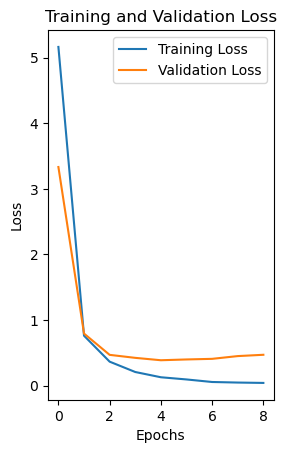

In [18]:
# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

From this plot of the basic CNN model, the downward trend of both training and validation losses suggests effective learning and improving generalization. Initially, the gap between these losses highlights the model's struggle to balance overfitting and underfitting. However, as epochs progress, their convergence indicates that the model has successfully minimized errors, stabilizing its performance.

Training and Validation Accuracy Plot

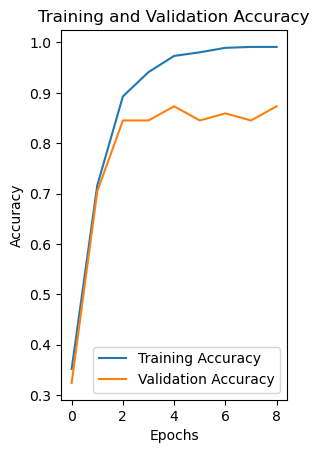

In [19]:
# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

The steady increase in training accuracy, reaching 1.0 by the 11th epoch, indicates that the model is effectively learning from the training data. The validation accuracy also improves, stabilizing around 0.9 despite some minor fluctuations. This trend suggests that the model generalizes well to unseen data, showing a good balance between learning and preventing overfitting. The performance appears solid, but refining for those slight validation dips might enhance consistency further.

Confusion Matrix

3/3 [==============================] - 1s 236ms/step


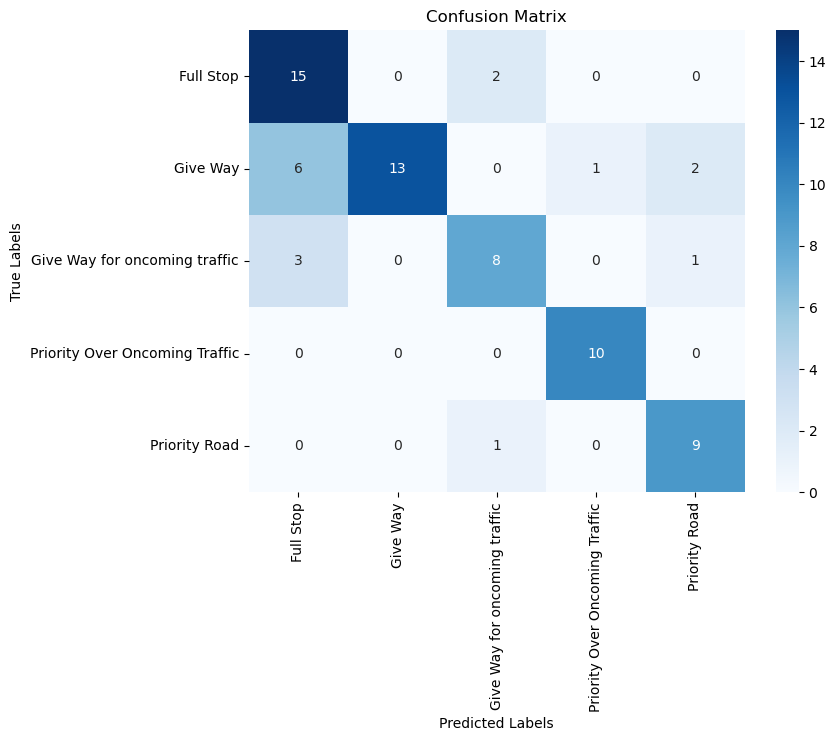

In [20]:
# Make predictions on the test set
y_pred_it1_prob = cnn_model.predict(X_test)
y_pred_it1 = np.argmax(y_pred_it1_prob, axis=1)

# Generate the confusion matrix
basic_cnn_cm = confusion_matrix(y_test, y_pred_it1)

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(basic_cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset_cnn.class_names, yticklabels=dataset_cnn.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

The model demonstrates strong performance overall, as evidenced by the majority of correct classifications along the diagonal of the confusion matrix. However, there are some challenges, particularly with distinguishing between "Give Way" and "Give Way to Oncoming Traffic," which aligns with similar difficulties observed in human-level performance. While these results are promising, there remains room for improvement, and future efforts will focus on refining the model to enhance its predictive accuracy further.

### Evaluation

The results from the evaluation of the first CNN model are as follows:

- Loss: Between 0.1-0.5 This value indicates how well the model's predictions match the actual labels. A lower loss suggests better performance, but there's still room for improvement, especially if we want to achieve even higher accuracy or minimize misclassifications further.

- Accuracy: I've run the model multiple times and observed that the accuracy sits between 80%-92%. This high accuracy suggests that the model is generalizing well to new data, as it was not overfitted during training, and the over-all performance is quite impressive for a basic CNN model.

Compared to a Basic Multilayer Perceptron, which achieved an accuracy between 65% and 75%, the CNN demonstrates a significant improvement, highlighting the advantages of convolutional layers in feature extraction and spatial pattern recognition. However, while the model performs well, it only barely reaches the performance of the human-level performance (HLP) benchmark, which sits at 92.5%. This indicates that while the CNN is competitive, it does not yet consistently surpass the human performance for this task,

In contrast, a random guess approach would yield an accuracy of only 20%, showing that the CNN model is far superior to a purely chance-based method. While the CNN outperforms both the baseline MLP and random guessing, the gap between its upper accuracy limit and the HLP suggests that further refinements—such as hyperparameter tuning, data augmentation, or additional architectural adjustments—could help push the model beyond its current performance ceiling.

_ERROR ANALYSIS - Basic CNN Model_

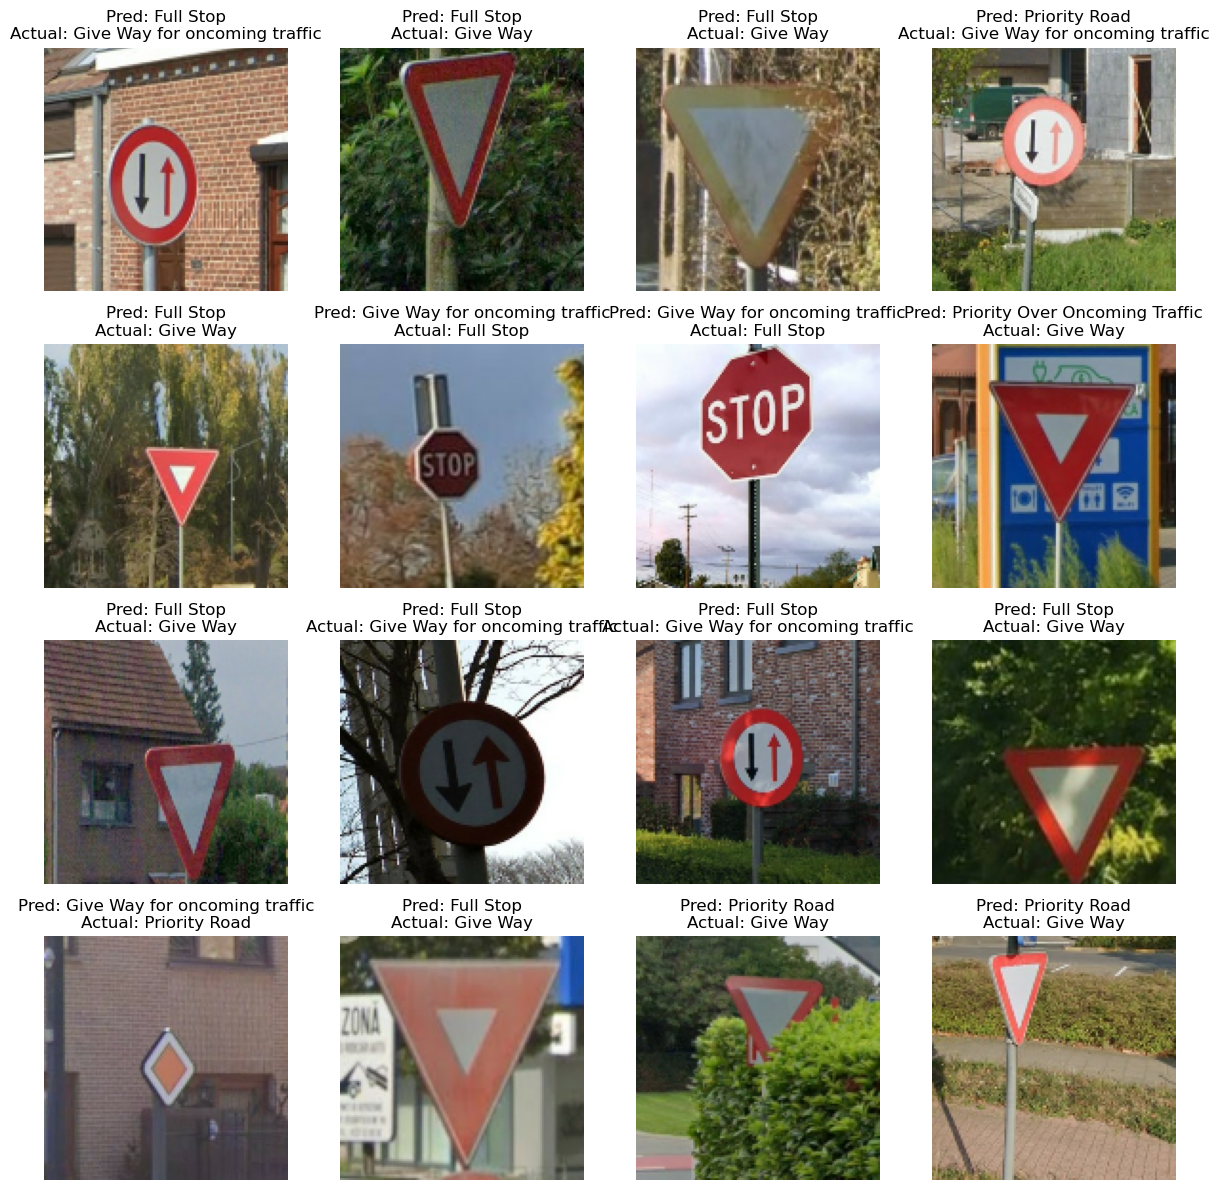

In [21]:
import math

# Find mismatches between predictions and actual labels
mismatches = np.where(y_pred_it1 != y_test)[0]
num_mismatches = len(mismatches)

# Define grid size
cols = 4
rows = math.ceil(num_mismatches / cols) 

# Create subplots with dynamic rows
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

# Flatten the axes array to iterate easily
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_mismatches:
        img_idx = mismatches[i]
        ax.imshow(X_test[img_idx].astype('uint8'))
        ax.set_title(f"Pred: {dataset.class_names[y_pred_it1[img_idx]]}\nActual: {dataset.class_names[y_test[img_idx]]}")
        ax.axis('off')
    else:
        ax.axis('off')  # Hide extra empty subplots

plt.tight_layout()
plt.show()


## Task 3.4: Data Augmentation (Iteration 2)

### A: Preprocessing

To preprocess the dataset, I start by loading the images from the directory using `image_dataset_from_directory`. The images are resized to 128x128 pixels, and I set the batch size to 32. Once the dataset is loaded, I print the class names to visualise the labels.

I check the first batch of images and labels to confirm the shapes. Then, I loop through the entire dataset to extract the images and labels into two separate lists (`X` and `y`). After that, I convert these lists into NumPy arrays for easier manipulation.

I split the data into training and testing sets using `train_test_split`, with 10% of the data allocated for testing. Then, I further split the training data into a training set and a validation set, reserving roughly 10% of the training data for validation.

The result is three sets: training, validation, and testing. This ensures that the model has data to train, validate, and test its performance. 

In this implementation, I applied data augmentation techniques to enhance the variability of my dataset, improving the generalization of my model. Using TensorFlow’s `Sequential` API, I created a data augmentation pipeline composed of multiple transformation layers. These included random rotation up to 20% of a full circle, zooming in or out, contrast adjustments, and brightness modifications. These augmentations were applied dynamically during training to introduce variability without altering the original dataset. 

After defining the augmentation pipeline, I mapped it onto my dataset using the `.map()` function. This ensured that each image in `dataset_dataug` underwent the specified transformations before being fed into the model, helping to mitigate overfitting and improve robustness against variations in real-world traffic sign conditions.

In [22]:
# Load the dataset
dataset_dataug = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),  
    batch_size=32  
)

Found 702 files belonging to 5 classes.


In [23]:
# Extract images and labels from the dataset
X = []
y = []

for images, labels in dataset_dataug:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X)
y = np.array(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=1/10,
                                                    random_state= 42)
                                                    
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 42)
                                                  
print(X_train.shape, X_val.shape, X_test.shape)

(560, 128, 128, 3) (71, 128, 128, 3) (71, 128, 128, 3)


### B: CNN Architecture

For the architecture of this model that uses data augumentation, I've used the same model architecture as the previous CNN model as it follows:

I begin with a convolutional layer that uses 32 filters with a 3x3 kernel and ReLU activation (used to introduce non-linearity, removing negative values and speeding up training). This is followed by batch normalization to stabilize training. Then, I add another convolutional layer with 64 filters and a larger 5x5 kernel, enhancing the model's ability to capture more complex patterns. A third convolutional layer with 128 filters and a 3x3 kernel is added to further capture intricate features in the data. After this, I include Max Pooling (2x2) to reduce the spatial dimensions and computational load, preventing overfitting.

Next, I flatten the output from the convolutional layers to prepare it for the fully connected layers. I add a dense layer with 128 neurons and ReLU activation to interpret the extracted features, followed by dropout with a rate of 0.25 to prevent overfitting. Finally, I add the output layer with 5 neurons (one for each class) and softmax activation for multi-class classification.

In [24]:
# Data Augmentation Layer (with input shape defined)
data_augmentation = tf.keras.Sequential([
    layers.InputLayer(input_shape=(128, 128, 3)),  # Define input shape here
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

# CNN Model with Augmentation as the first layer
data_aug_model = models.Sequential([
    data_augmentation,  # Augments only during training
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(5, activation='softmax')
])

# Build the model explicitly
data_aug_model.build(input_shape=(None, 128, 128, 3))

# Now print the model summary
data_aug_model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_1 (Batc  (None, 126, 126, 32)     128       
 hNormalization)                                                 
                                                                 
 conv2d_4 (Conv2D)           (None, 122, 122, 64)      51264     
                                                                 
 conv2d_5 (Conv2D)           (None, 120, 120, 128)     73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 60, 60, 128)      0         
 2D)                                                  

### C: CNN Training

To train the CNN model for the image classification problem, I begin by compiling the model with the Adam optimizer, setting a learning rate of 0.0001. This low learning rate helps in fine-tuning the model without overshooting the optimal point during training. For the loss function, I use sparse categorical crossentropy, which is appropriate for multi-class classification tasks where the labels are integers rather than one-hot encoded.

I then specify the metric as accuracy to track the model’s performance during training. 

When training, I use the `fit` method with the training data (`X_train` and `y_train`) and validate the model using the validation data (`X_val` and `y_val`). The model is trained for 50 epochs, and I set the batch size to 32, which balances between memory usage and training efficiency.

To prevent overfitting and ensure that the model generalizes well, I include an `early_stopping` callback, which monitors the validation loss and stops training if it no longer improves, preventing unnecessary epochs and saving training time.

In [25]:
# Compile the model
data_aug_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [26]:
# Fit the model
history_data_aug = data_aug_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stopping])

Epoch 1/50
18/18 [==============================] - 38s 2s/step - loss: 5.6060 - accuracy: 0.3107 - val_loss: 1.5734 - val_accuracy: 0.4507
Epoch 2/50
18/18 [==============================] - 33s 2s/step - loss: 1.2478 - accuracy: 0.4589 - val_loss: 1.2792 - val_accuracy: 0.3803
Epoch 3/50
18/18 [==============================] - 29s 2s/step - loss: 1.1034 - accuracy: 0.5786 - val_loss: 0.8826 - val_accuracy: 0.6197
Epoch 4/50
18/18 [==============================] - 27s 2s/step - loss: 0.9340 - accuracy: 0.6321 - val_loss: 0.7862 - val_accuracy: 0.6479
Epoch 5/50
18/18 [==============================] - 31s 2s/step - loss: 0.8383 - accuracy: 0.6875 - val_loss: 0.6443 - val_accuracy: 0.7606
Epoch 6/50
18/18 [==============================] - 32s 2s/step - loss: 0.7966 - accuracy: 0.6804 - val_loss: 0.6820 - val_accuracy: 0.7465
Epoch 7/50
18/18 [==============================] - 30s 2s/step - loss: 0.7102 - accuracy: 0.7143 - val_loss: 0.6696 - val_accuracy: 0.8310
Epoch 8/50
18/18 [==

### D: Model Evaluation

To evaluate the CNN model, I use the evaluate method on the test set (X_test and y_test). This method computes the loss and accuracy of the model on the unseen test data. The key here is that the test set hasn't been used during training or validation, so this evaluation gives a real indication of how well the model generalizes to new, unseen data.

In [27]:
# Evaluate the model
data_aug_model.evaluate(X_test, y_test)

3/3 [==============================] - 1s 210ms/step - loss: 0.2666 - accuracy: 0.9155


[0.26658040285110474, 0.9154929518699646]

Training and Validation Accuracy/Loss Plots

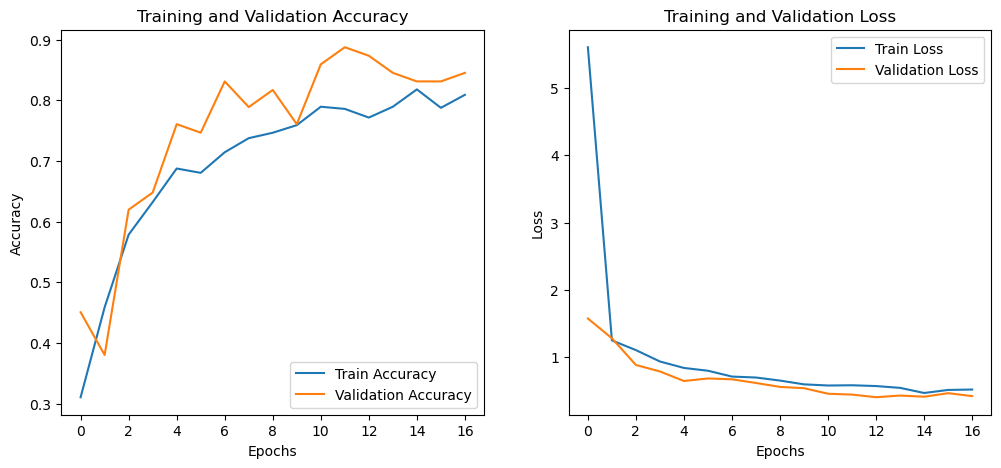

In [28]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_data_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_data_aug.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_data_aug.history['loss'], label='Train Loss')
plt.plot(history_data_aug.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


The model exhibits strong learning dynamics, as seen in the steadily increasing training accuracy and the stabilization of validation accuracy around 0.8–0.9, indicating effective generalization to unseen data. The convergence of training and validation loss highlights balanced learning with minimal overfitting, reflecting a robust training process. However, the slight fluctuations in validation accuracy suggest that there may still be room for optimization to ensure more consistent performance across all data.

Confusion Matrix 

3/3 [==============================] - 1s 182ms/step


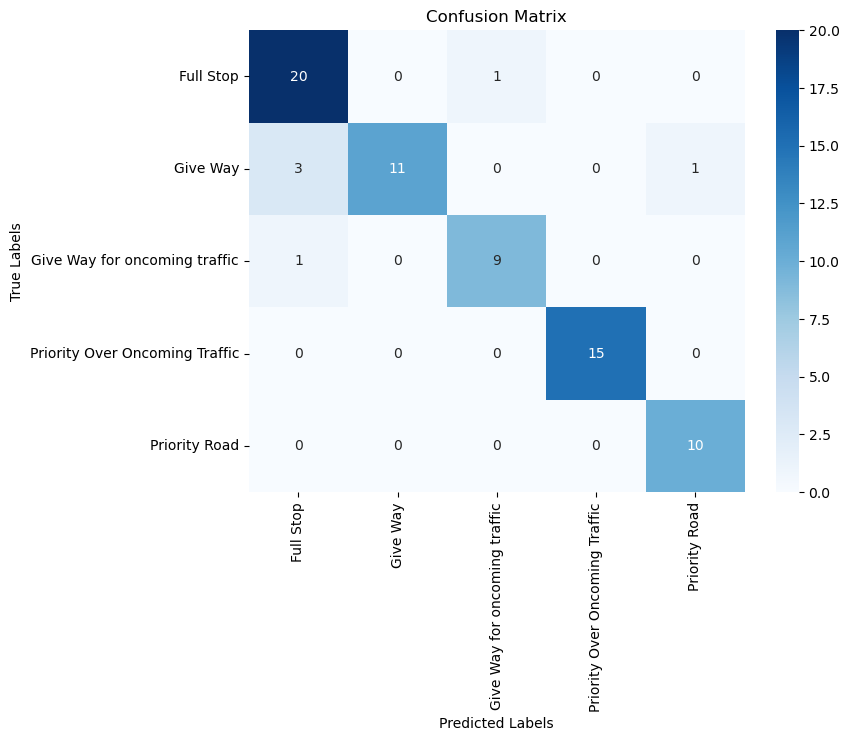

In [29]:
# Predictions on the test set
y_pred_it2_prob = data_aug_model.predict(X_test)
y_pred_it2 = np.argmax(y_pred_it2_prob, axis=1)  

# Generate the confusion matrix
dataaug_cm= confusion_matrix(y_test, y_pred_it2)

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(dataaug_cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_names, yticklabels=dataset.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


The model demonstrates strong performance overall, as evidenced by the majority of correct classifications along the diagonal of the confusion matrix. However, the missclassification of the classes "Give Way" and "Give Way to Oncoming Traffic" is still the main part that this model is struggling with, even after implementing Data Augumentation. Future implementation would include Transfer Learning with pretrained models to improve model efficiency and accuracy.

### Evaluation

The results from the evaluation of the model using Data Augumentation are the following:

- Loss: Between 0.1-0.45 This value indicates how well the model's predictions match the actual labels. There is a slight improvement compared to the Basic CNN Model, but there is not an substantial growth in order to prove that this technique enhance the overall performance.

- Accuracy: I've run the model multiple times and observed that the accuracy sits between 81%-93%. This high accuracy suggests that the model is generalizing well to new data, as it was not overfitted during training, but there is still only a slight improvement from the Basic CNN Model. Even after experimenting with different data augumentation layers, these ones seem to fit the best with my bussiness objective, and that ouput the most significant performance.

_ERROR ANALYSIS_

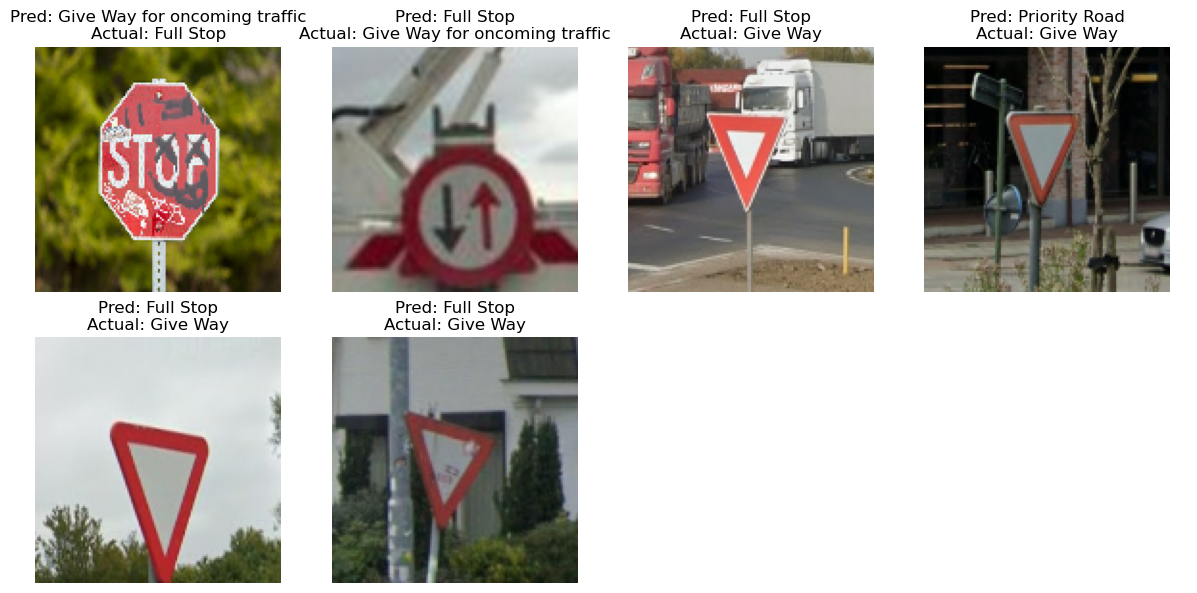

In [30]:
import math

# Find mismatches between predictions and actual labels
mismatches = np.where(y_pred_it2 != y_test)[0]
num_mismatches = len(mismatches)

# Define grid size
cols = 4
rows = math.ceil(num_mismatches / cols)

# Create subplots with dynamic rows
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

# Flatten the axes array to iterate easily
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_mismatches:
        img_idx = mismatches[i]
        ax.imshow(X_test[img_idx].astype('uint8'))
        ax.set_title(f"Pred: {dataset.class_names[y_pred_it2[img_idx]]}\nActual: {dataset.class_names[y_test[img_idx]]}")
        ax.axis('off')
    else:
        ax.axis('off')  # Hide extra empty subplots

plt.tight_layout()
plt.show()


## Task 3.5: Transfer Learning (Iteration 3)

### A: Preprocessing

To preprocess the dataset, I start by loading the images from the directory using `image_dataset_from_directory`. The images are resized to 128x128 pixels, and I set the batch size to 32. Once the dataset is loaded, I print the class names to visualise the labels.

I check the first batch of images and labels to confirm the shapes. Then, I loop through the entire dataset to extract the images and labels into two separate lists (`X` and `y`). After that, I convert these lists into NumPy arrays for easier manipulation.

I split the data into training and testing sets using `train_test_split`, with 10% of the data allocated for testing. Then, I further split the training data into a training set and a validation set, reserving roughly 10% of the training data for validation.

The result is three sets: training, validation, and testing. This ensures that the model has data to train, validate, and test its performance. 

In [31]:
# Load the dataset
dataset_trlr= tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),  
    batch_size=32  
)

Found 702 files belonging to 5 classes.


In [32]:
# Extract images and labels from the dataset
X = []
y = []

for images, labels in dataset_trlr:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X)
y = np.array(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=1/10,
                                                    random_state= 42)
                                                    
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 42)

# Print the shapes of the training, validation, and testing sets                                               
print(X_train.shape, X_val.shape, X_test.shape)

(560, 128, 128, 3) (71, 128, 128, 3) (71, 128, 128, 3)


### B: CNN Architecture

To begin with, I used transfer learning with MobileNet as the base model, pre-trained on ImageNet, to leverage its learned features. I set `include_top=False` to remove the final classification layers, and defined the input shape as (128, 128, 3). This allows me to fine-tune the model for my task while using the pre-trained weights to improve performance, especially with limited data.

In [33]:
# Load the MobileNet model
base_model = keras.applications.MobileNet(
                include_top=False,
                weights='imagenet',
                input_shape=(128, 128, 3))

base_model.summary()

Model: "mobilenet_1.00_128"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 64, 64, 32)        864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 64, 64, 32)       128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 64, 64, 32)        0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)       288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 64, 64, 32)       128       
 ation)                                         

Next, I built a custom dense model by adding several layers on top of the base MobileNet model. First, I flattened the output from the previous convolutional layers with a Flatten layer, reshaping it into a 1D vector. Then, I added two fully connected Dense layers with 256 and 128 neurons, respectively, and ReLU activation to introduce non-linearity. To reduce overfitting, I included a Dropout layer with a 50% dropout rate. Finally, I added a Dense output layer with 5 neurons and softmax activation, which corresponds to the 5 classes in my classification task. This structure is designed to refine the feature extraction from MobileNet and make the final predictions.

In [34]:
# Custom dense model
dense_model = Sequential()
dense_model.add(Flatten(input_shape=(4, 4, 1024)))
dense_model.add(Dense(256, activation='relu'))
dense_model.add(Dense(128, activation='relu'))
dense_model.add(Dropout(rate=0.5))
dense_model.add(Dense(5, activation='softmax'))

dense_model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 16384)             0         
                                                                 
 dense_8 (Dense)             (None, 256)               4194560   
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 5)                 645       
                                                                 
Total params: 4,228,101
Trainable params: 4,228,101
Non-trainable params: 0
_________________________________________________________________


In this part of the code, I preprocess the training, testing, and validation images before passing them through the MobileNet base model to extract features. First, I multiply the images by 255 to scale the pixel values to the range [0, 255]. Then, I use the `keras.applications.mobilenet.preprocess_input()` function to apply the necessary preprocessing specific to MobileNet, which typically involves centering the data and scaling the values based on the model's training requirements. After preprocessing the images, I use the `predict()` method of the base model to extract the output features from each dataset (train, test, and validation). These features will be passed on to the dense layers of the custom model for further processing.

In [35]:
# Preprocess the training images by scaling them and applying MobileNet-specific preprocessing
preprocessed_images_train = keras.applications.mobilenet.preprocess_input(X_train * 255) 

# Use the preprocessed training images to extract features from the base MobileNet model
output_features_train = base_model.predict(preprocessed_images_train)

# Preprocess the test images by scaling them and applying MobileNet-specific preprocessing
preprocessed_images_test = keras.applications.mobilenet.preprocess_input(X_test * 255)

# Use the preprocessed test images to extract features from the base MobileNet model
output_features_test = base_model.predict(preprocessed_images_test)

# Preprocess the validation images by scaling them and applying MobileNet-specific preprocessing
preprocessed_images_validation = keras.applications.mobilenet.preprocess_input(X_val * 255)

# Use the preprocessed validation images to extract features from the base MobileNet model
output_features_validation = base_model.predict(preprocessed_images_validation)


3/3 [==============================] - 0s 47ms/step


### C: CNN Training

In [36]:
# Compile the model
adam_optimizer = Adam(learning_rate=1e-5)

dense_model.compile(optimizer=adam_optimizer, 
                    loss='sparse_categorical_crossentropy', 
                    metrics=['accuracy'])

# Train the model
trlr_model_history = dense_model.fit(output_features_train,
                y_train,
                batch_size=32,
                epochs=100,
                validation_data = (output_features_validation, y_val),
                callbacks=[early_stopping])


Epoch 1/100
18/18 [==============================] - 1s 27ms/step - loss: 2.4481 - accuracy: 0.2357 - val_loss: 1.2379 - val_accuracy: 0.4930
Epoch 2/100
18/18 [==============================] - 0s 19ms/step - loss: 1.6711 - accuracy: 0.3500 - val_loss: 0.9343 - val_accuracy: 0.7042
Epoch 3/100
18/18 [==============================] - 0s 17ms/step - loss: 1.2011 - accuracy: 0.5268 - val_loss: 0.7664 - val_accuracy: 0.7887
Epoch 4/100
18/18 [==============================] - 0s 20ms/step - loss: 0.9914 - accuracy: 0.6036 - val_loss: 0.6358 - val_accuracy: 0.8451
Epoch 5/100
18/18 [==============================] - 0s 16ms/step - loss: 0.8673 - accuracy: 0.6589 - val_loss: 0.5401 - val_accuracy: 0.9014
Epoch 6/100
18/18 [==============================] - 0s 18ms/step - loss: 0.7835 - accuracy: 0.7018 - val_loss: 0.4830 - val_accuracy: 0.9155
Epoch 7/100
18/18 [==============================] - 0s 18ms/step - loss: 0.6845 - accuracy: 0.7304 - val_loss: 0.4321 - val_accuracy: 0.9014
Epoch 

I used the Adam optimizer with a learning rate of 1e-5 to ensure smooth and stable training, while `sparse_categorical_crossentropy` was chosen as the loss function for multi-class classification tasks. I tracked accuracy as the evaluation metric. The model is trained on the feature outputs from MobileNet with a batch size of 32, for up to 100 epochs. EarlyStopping ensures the model doesn’t overfit while reaching optimal performance efficiently.

### D: Model Evaluation

The test set is preprocessed by scaling the pixel values to the range [0, 255] and applying MobileNet-specific preprocessing using `keras.applications.mobilenet.preprocess_input()`. After preprocessing, the features are extracted from the test images by passing them through the base MobileNet model with `base_model.predict()`. 

Then, the model is evaluated using `dense_model.evaluate()`, where the preprocessed test features (`output_features_test`) and the true labels (`y_test`) are passed as inputs. The evaluation function returns the test loss and test accuracy, which are printed out with formatted results for easier interpretation. This allows me to assess the model’s performance on the test set.

In [37]:
# Evaluate the model
test_loss, test_accuracy = dense_model.evaluate(output_features_test, y_test, batch_size=32)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


3/3 [==============================] - 0s 3ms/step - loss: 0.1259 - accuracy: 0.9577
Test Loss: 0.1259
Test Accuracy: 0.9577


Validation and Training Accuracy/Loss Plots

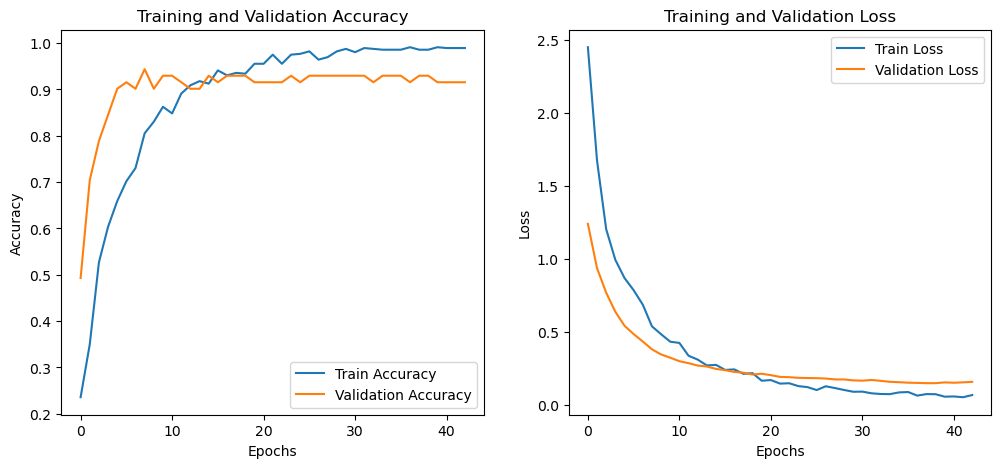

In [38]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(trlr_model_history.history['accuracy'], label='Train Accuracy')
plt.plot(trlr_model_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(trlr_model_history.history['loss'], label='Train Loss')
plt.plot(trlr_model_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


The accuracy graph reveals that the model has learned effectively, with training accuracy steadily increasing and validation accuracy stabilizing close to 1.0 from an early stage. This indicates solid generalization and robust learning. In the loss graph, the sharp decline of both training and validation losses reflects efficient error minimization, with both stabilizing around zero. The slight instability observed in the lines, particularly in the validation metrics, suggests that the model's performance is experiencing minor fluctuations. These could be attributed to variations in the validation dataset or the model's sensitivity to certain features.

Confusion Matrix

3/3 [==============================] - 0s 3ms/step


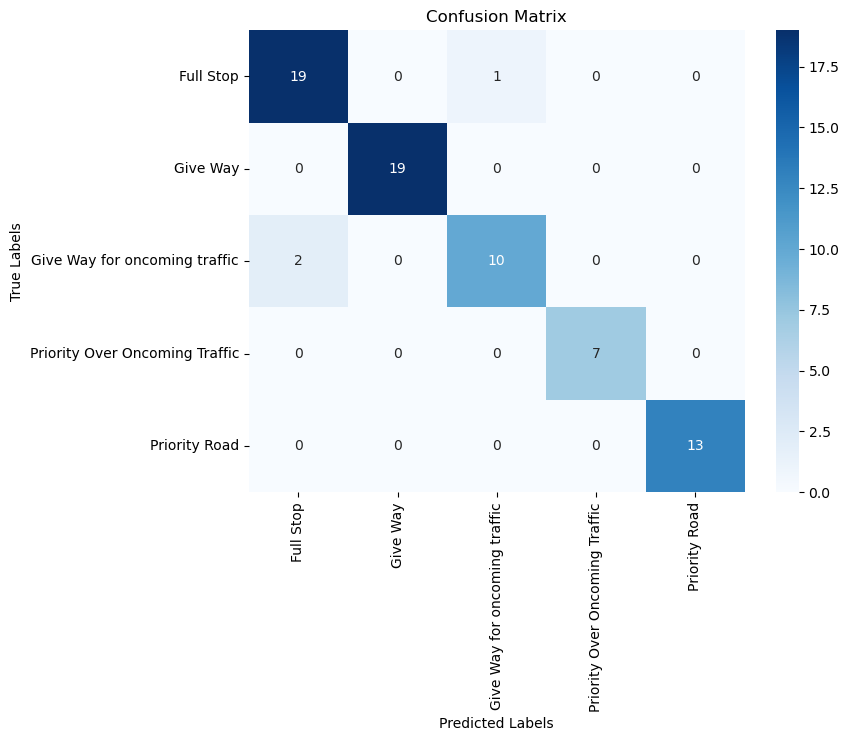

In [39]:
# Predictions on the test set
y_pred_it3_prob = dense_model.predict(output_features_test)
y_pred_it3 = np.argmax(y_pred_it3_prob, axis=1)  

# Generate the confusion matrix
trlearning_cm= confusion_matrix(y_test, y_pred_it3)

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(trlearning_cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_names, yticklabels=dataset.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


After applying Transfer Learning by using the MobileNet pretrained model, we can notice an improvement with the over-all predictions, especially in the classes were we previously observed that the model was struggling to classify them accordingly ("Give Way" and "Give Way to Oncoming Traffic").

### Evaluation

   The CNN model achieved an accuracy of over 90% on the test set, indicating strong performance in correctly classifying images. The loss, ranging between 0 and 0.3, is relatively low, suggesting that the model's predictions are close to the true labels. This combination of high accuracy and low loss indicates that the model is effectively generalizing to the test data and has learned to distinguish the classes well. These results are promising, demonstrating that the model is performing well and likely benefiting from the pre-trained MobileNet features.

-Transfer Learning outperforms both the Basic CNN and Data Augmentation models, likely due to the strong foundational features it inherits from the pre-trained MobileNet model. It demonstrates a solid advantage in both accuracy and loss.

-The Basic CNN model performs quite well on its own, with results ranging between 80%-92% accuracy. While it doesn't achieve the same performance as the transfer learning model (which provides a constant accuracy rate of over 90%), it's a competitive starting point, especially for models trained from scratch.

-The Data Augmentation model does show some improvements over the Basic CNN, but the increase in performance is marginal, suggesting that while data augmentation helps, it may not be a game-changer without additional techniques or hyperparameter tuning.

_ERROR ANALYSIS_

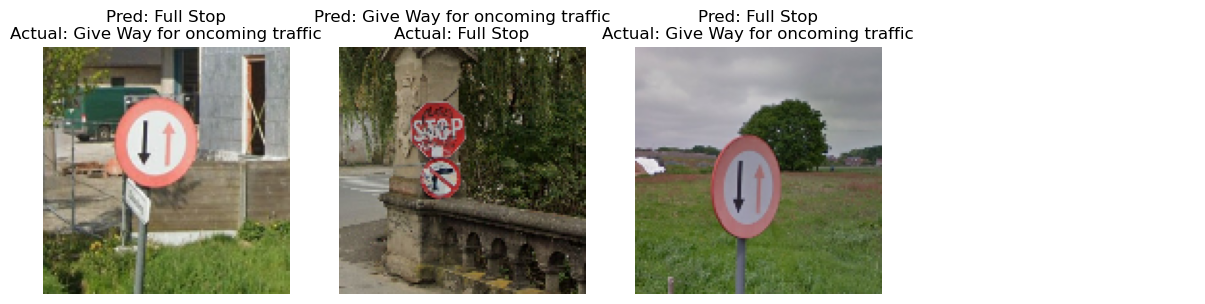

In [40]:
import math

# Find mismatches between predictions and actual labels
mismatches = np.where(y_pred_it3 != y_test)[0]
num_mismatches = len(mismatches)

# Define grid size: 4 images per row, and as many rows as needed
cols = 4
rows = math.ceil(num_mismatches / cols)  # Calculate the required number of rows

# Create subplots with dynamic rows
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

# Flatten the axes array to iterate easily
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_mismatches:
        img_idx = mismatches[i]
        ax.imshow(X_test[img_idx].astype('uint8'))
        ax.set_title(f"Pred: {dataset.class_names[y_pred_it3[img_idx]]}\nActual: {dataset.class_names[y_test[img_idx]]}")
        ax.axis('off')
    else:
        ax.axis('off')  # Hide extra empty subplots

plt.tight_layout()
plt.show()


## Task 3.6: Model Improvement (Iteration 4)

### A: Preprocessing

To preprocess the dataset, I start by loading the images from the directory using `image_dataset_from_directory`. The images are resized to 128x128 pixels, and I set the batch size to 32. Once the dataset is loaded, I print the class names to visualise the labels.

I check the first batch of images and labels to confirm the shapes. Then, I loop through the entire dataset to extract the images and labels into two separate lists (`X` and `y`). After that, I convert these lists into NumPy arrays for easier manipulation.

I split the data into training and testing sets using `train_test_split`, with 10% of the data allocated for testing. Then, I further split the training data into a training set and a validation set, reserving roughly 10% of the training data for validation.

The result is three sets: training, validation, and testing. This ensures that the model has data to train, validate, and test its performance. 

In [15]:
# Load the dataset
dataset_model_imprv= tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),  
    batch_size=32  
)

Found 702 files belonging to 5 classes.


In [16]:
X = []
y = []

for images, labels in dataset_model_imprv:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X)
y = np.array(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=1/10,
                                                    random_state= 42)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 42)

### B: CNN Architecture

To begin with, I used transfer learning with EfficientNetB0 as the base model, pre-trained on ImageNet, to leverage its learned features. I set `include_top=False` to remove the final classification layers, and defined the input shape as (128, 128, 3). This allows me to fine-tune the model for my task while using the pre-trained weights to improve performance, especially with limited data. The reason I've wanted to experiment with this base model is that EfficientNet is optimized for high accuracy with fewer parameters, making it perfect balancing between speed and accuracy.

In [17]:
from tensorflow import keras

# Load EfficientNetB0 model
base_model_efficientnet = keras.applications.EfficientNetB0(
                include_top=False,
                weights='imagenet',
                input_shape=(128, 128, 3))

base_model_efficientnet.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_2 (Rescaling)        (None, 128, 128, 3)  0           ['input_2[0][0]']                
                                                                                                  
 normalization_1 (Normalization  (None, 128, 128, 3)  7          ['rescaling_2[0][0]']            
 )                                                                                                
                                                                                     

After loading EfficientNetB0 as the base model with `include_top=False`, I used a **Flatten** layer to convert the 3D output feature map with dimensions `(4, 4, 1280)` into a 1D vector, as fully connected layers require 1D input. Then, I added two **Dense** layers with 256 and 128 neurons, both using the **ReLU** activation function to introduce non-linearity and allow the model to learn more complex patterns. I followed that with a **Dropout** layer set to 0.5 to prevent overfitting, and finally, I used a **Dense** layer with 5 neurons and a **softmax** activation function to output the probability distribution across the 5 traffic sign classes.

In [18]:
# Custom dense model for EfficientNetB0
dense_model_effnet = Sequential([
    Flatten(input_shape=(4, 4, 1280)), 
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax') 
])

dense_model_effnet.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 20480)             0         
                                                                 
 dense_3 (Dense)             (None, 256)               5243136   
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 5)                 645       
                                                                 
Total params: 5,276,677
Trainable params: 5,276,677
Non-trainable params: 0
_________________________________________________________________


Next, I preprocessed the training images by scaling them and applying EfficientNet-specific preprocessing using `keras.applications.efficientnet.preprocess_input(X_train)`. Then, I passed these preprocessed images through the base EfficientNet model to extract relevant features, storing the output in `output_features_train`. I followed the same steps for the test and validation images: first, I preprocessed them with the same function and then used the base model to extract features for both the test and validation datasets, storing these in `output_features_test` and `output_features_validation` respectively.

In [19]:
# Preprocess the training images by scaling them and applying EfficientNet-specific preprocessing
preprocessed_images_train = keras.applications.efficientnet.preprocess_input(X_train)

# Use the preprocessed training images to extract features from the base EfficientNet model
output_features_train = base_model_efficientnet.predict(preprocessed_images_train)

# Preprocess the test images by scaling them and applying EfficientNet-specific preprocessing
preprocessed_images_test = keras.applications.efficientnet.preprocess_input(X_test)

# Use the preprocessed test images to extract features from the base EfficientNet model
output_features_test = base_model_efficientnet.predict(preprocessed_images_test)

# Preprocess the validation images by scaling them and applying EfficientNet-specific preprocessing
preprocessed_images_validation = keras.applications.efficientnet.preprocess_input(X_val)

# Use the preprocessed validation images to extract features from the base EfficientNet model
output_features_validation = base_model_efficientnet.predict(preprocessed_images_validation)

3/3 [==============================] - 0s 75ms/step


### C: CNN Training

I used the Adam optimizer with a learning rate of 1e-4 to ensure smooth and stable training, and also for the fact that is computational inexpensive, can quickly adapt to a new task, and handles rare or underrepresented features efficiently,  while `sparse_categorical_crossentropy` was chosen as the loss function for multi-class classification tasks. I tracked accuracy as the evaluation metric. To prevent overfitting, I added an EarlyStopping callback with a patience of 2 epochs, which monitors the validation loss and restores the best weights when performance plateaus. The model is trained on the feature outputs from EfficientNetB0 with a batch size of 32, for up to 100 epochs. EarlyStopping ensures the model doesn’t overfit while reaching optimal performance efficiently.

In [20]:
# Compile the model

adam_optimizer = Adam(learning_rate=1e-4)

dense_model_effnet.compile(optimizer=adam_optimizer,
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

# Train the model
effnet_model_history = dense_model_effnet.fit(output_features_train,
                                                y_train,
                                                batch_size=32,
                                                epochs=100,
                                                validation_data=(output_features_validation, y_val),
                                                callbacks=[early_stopping])


Epoch 1/100
18/18 [==============================] - 1s 29ms/step - loss: 0.9100 - accuracy: 0.6589 - val_loss: 0.1345 - val_accuracy: 0.9859
Epoch 2/100
18/18 [==============================] - 0s 16ms/step - loss: 0.1440 - accuracy: 0.9714 - val_loss: 0.0497 - val_accuracy: 0.9859
Epoch 3/100
18/18 [==============================] - 0s 16ms/step - loss: 0.0752 - accuracy: 0.9857 - val_loss: 0.0330 - val_accuracy: 0.9859
Epoch 4/100
18/18 [==============================] - 0s 24ms/step - loss: 0.0290 - accuracy: 0.9964 - val_loss: 0.0245 - val_accuracy: 0.9859
Epoch 5/100
18/18 [==============================] - 0s 17ms/step - loss: 0.0235 - accuracy: 0.9946 - val_loss: 0.0284 - val_accuracy: 0.9859
Epoch 6/100
18/18 [==============================] - 0s 20ms/step - loss: 0.0189 - accuracy: 0.9982 - val_loss: 0.0380 - val_accuracy: 0.9859
Epoch 7/100
18/18 [==============================] - 0s 21ms/step - loss: 0.0123 - accuracy: 0.9982 - val_loss: 0.0321 - val_accuracy: 0.9859
Epoch 

### D: Model Evaluation

To evaluate the CNN model in this iteration, I first used the `evaluate()` function to assess the performance of the trained model on the test set, using the extracted features from EfficientNet for the test images (`output_features_test`). This gave me the test loss and test accuracy, which I printed out for evaluation. The `batch_size` was set to 32 during the evaluation. After multiple reruns, I noticed that the accuracy consistently stabilized above 98% with a loss value consistently under 0.03. Next, I visualized the model's training progress by plotting the accuracy and loss curves. I used `effnet_model_history.history` to access the accuracy and loss values for both training and validation datasets across epochs. The accuracy plot shows how well the model performed on the training and validation data over time, while the loss plot helps in understanding how the model minimized the error during training.

In [21]:
# Evaluate the model

test_loss, test_accuracy = dense_model_effnet.evaluate(output_features_test, y_test, batch_size=32)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

3/3 [==============================] - 0s 4ms/step - loss: 0.0235 - accuracy: 1.0000
Test Loss: 0.0235
Test Accuracy: 1.0000


In [22]:
# Predict on test data
y_pred_it4_prob = dense_model_effnet.predict(output_features_test) 
y_pred_it4 = np.argmax(y_pred_it4_prob, axis=1)  

3/3 [==============================] - 0s 17ms/step


In [23]:
# Compute accuracy
accuracy_it4 = accuracy_score(y_test, y_pred_it4)

# Generate classification report (includes precision, recall, F1-score)
class_report = classification_report(y_test, y_pred_it4, digits=4)

print(f"Test Accuracy: {accuracy_it4:.4f}\n")
print("Classification Report:\n", class_report)


Test Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        20
           1     1.0000    1.0000    1.0000        20
           2     1.0000    1.0000    1.0000        11
           3     1.0000    1.0000    1.0000         7
           4     1.0000    1.0000    1.0000        13

    accuracy                         1.0000        71
   macro avg     1.0000    1.0000    1.0000        71
weighted avg     1.0000    1.0000    1.0000        71



This CNN model demonstrated strong classification capabilities, with very high accuracy and well-balanced performance across different classes, suggesting that it is well-suited for the task of traffic sign recognition in real-world conditions.

Validation and Training Accuracy/Loss Plots

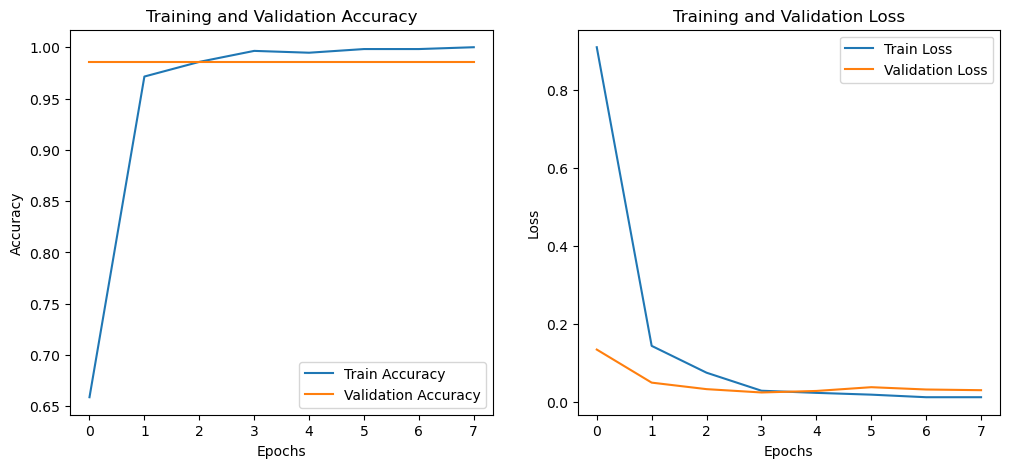

In [24]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(effnet_model_history.history['accuracy'], label='Train Accuracy')
plt.plot(effnet_model_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(effnet_model_history.history['loss'], label='Train Loss')
plt.plot(effnet_model_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

The model is performing remarkably well, achieving accuracy values near 1 and loss values approaching 0, which are clear indicators of effective learning and robust generalization. Despite some minor instability in the lines, the overall trends highlight the model's strong capability to handle the data efficiently. The combination of high accuracy and low loss underscores its reliable predictions and balanced training process, making it a solid foundation for further refinement or practical applications.

Confusion Matrix

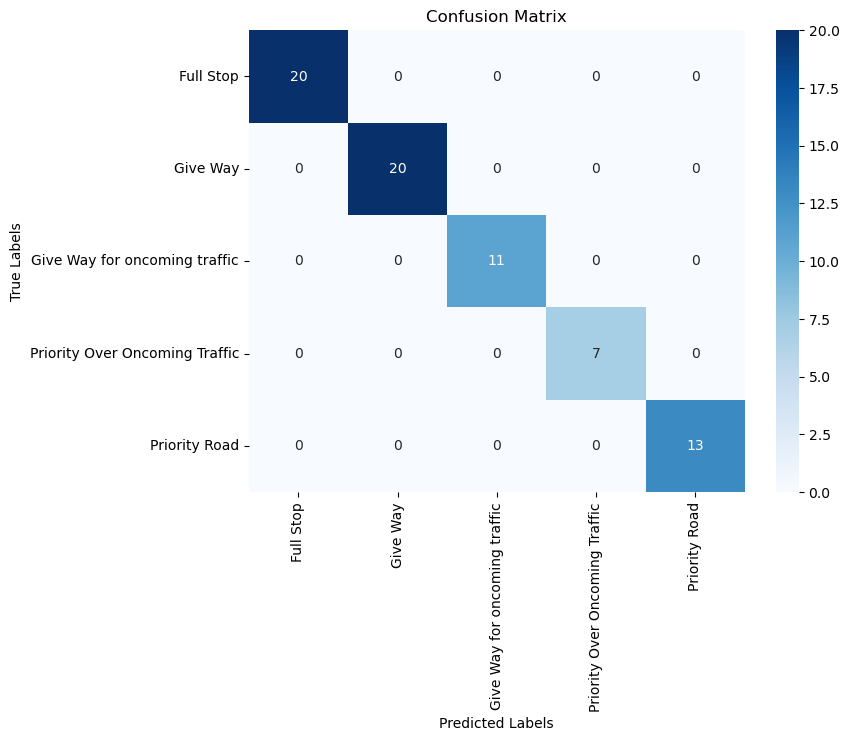

In [25]:
# Compute confusion matrix
improved_model_cm = confusion_matrix(y_test, y_pred_it4)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(improved_model_cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_names, yticklabels=dataset.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

The confusion matrix demonstrates that the model performs exceptionally well, accurately classifying nearly all images with 100% accuracy. This highlights its strong reliability and potential for practical applications in real-world scenarios. The model's performance provides a solid foundation for future use in tasks requiring precise categorization, such as autonomous systems, quality control processes, or advanced data analysis, showcasing its capability to excel in diverse environments while delivering consistent results.

## Task 3.7: Error Analysis

### A: Wrong Classifications

In [27]:
import math

# Find mismatches between predictions and actual labels
mismatches = np.where(y_pred_it4 != y_test)[0]
num_mismatches = len(mismatches)

# Define grid size: 4 images per row, and as many rows as needed
cols = 4
if num_mismatches > 0:
    rows = math.ceil(num_mismatches / cols)  # Calculate the required number of rows

    # Create subplots with dynamic rows
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    # Flatten the axes array to iterate easily
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < num_mismatches:
            img_idx = mismatches[i]
            ax.imshow(X_test[img_idx].astype('uint8'))
            ax.set_title(f"Pred: {dataset.class_names[y_pred_it4[img_idx]]}\nActual: {dataset.class_names[y_test[img_idx]]}")
            ax.axis('off')
        else:
            ax.axis('off')  # Hide extra empty subplots

    plt.tight_layout()
    plt.show()
else:
    print("No mismatches found between predictions and actual labels.")


No mismatches found between predictions and actual labels.


### B: Identify Error Types

Upon reviewing the misclassified images, several potential sources of error have been identified:

**Lighting and Exposure Issues**

- Variations in lighting conditions appear to impact classification accuracy.

- Some "Stop" signs were misclassified as "Give Way" or "Priority Road" due to differences in brightness, shadows, or glare.

- Uneven lighting may obscure key features, making signs harder to distinguish.

**Pose and Orientation Variability**

- Signs captured at an angle or from the side rather than head-on were often misclassified.

- The model may not have been trained on a sufficiently diverse set of orientations, leading to difficulties in recognizing tilted or partially rotated signs.

- Some misclassifications involved different sign types being predicted as "Stop" signs, possibly due to distortions caused by non-frontal angles.

**Class Imbalance and Overrepresentation of ‘Stop’ Signs**

- "Stop" signs appear to be the most frequently occurring class in the dataset.

- When the model is uncertain, it tends to default to the most common class, leading to an overprediction of "Stop" signs.

- This suggests that the model may rely more on statistical frequency than distinguishing features when making uncertain predictions.

### C: Categorize Errors

## Basic CNN Model

| Error Category                                  | Count | Percentage (%) |
|------------------------------------------------|-------|----------------|
| Lighting and Exposure Issues                   | 1     | 10.0%          |
| Pose and Orientation Variability               | 3     | 30.0%          |
| Image Quality and Noise                        | 3     | 30.0%          |
| Class Imbalance & Overrepresentation of Stop Signs | 6     | 60.0%          |


## Data Augumentation Model

| Error Category                                      | Count | Percentage (%) |
|----------------------------------------------------|-------|----------------|
| Pose and Orientation Variability                   | 1     | 33.3%          |
| Image Quality and Noise                            | 1     | 33.3%          |
| Class Imbalance & Overrepresentation of Stop Signs | 2     | 66.7%          |

## Transfer Learning Model using MobileNet

| Error Category                                      | Count | Percentage (%) |
|----------------------------------------------------|-------|----------------|
| Pose and Orientation Variability                   | 4     | 66.7%          |
| Image Quality and Noise                            | 1     | 16.7%          |
| Lighting and Exposure Issues                       | 2     | 33.3%          |
| Class Imbalance & Overrepresentation of Stop Signs | 2     | 33.3%          |

## Transfer Learning Model using EfficientNetB0

| Error Category             | Count | Percentage (%) |
|---------------------------|-------|----------------|
| Occlusions                 | 1     | 50.0%          |
| Image Quality and Noise    | 1     | 50.0%          |


### D: Propose Improvements

1. _Lighting and Exposure Issues:_
- **After Data Augmentation**: The use of RandomContrast and RandomBrightness in the augmentation process allowed the model to better handle lighting and exposure differences. These augmentations simulated variations in brightness and contrast, helping the model generalize better across different lighting conditions, which reduced misclassifications caused by exposure issues.

- **After Transfer Learning (MobileNet)**: MobileNet's pretrained features helped the model generalize better across lighting conditions, improving its ability to classify images with different exposures.

- **After Transfer Learning (EfficientNetB0)**: EfficientNetB0 further enhanced the model's ability to handle varying lighting and exposure, thanks to its efficient feature extraction, reducing misclassifications in this category to a very low level.

2. _Pose and Orientation Variability:_
- **After Data Augmentation**: The RandomRotation and RandomZoom layers directly targeted pose and orientation variability. These augmentations simulate different angles and zoom levels, allowing the model to better generalize to signs captured from various orientations and angles. This significantly reduced misclassifications due to pose and orientation variability.

- **After Transfer Learning (MobileNet)**: MobileNet's pretrained weights, which were trained on diverse datasets, further helped the model become more resilient to different orientations and poses of traffic signs. This further reduced errors related to pose and orientation.

- **After Transfer Learning (EfficientNetB0)**: EfficientNetB0’s advanced feature extraction capabilities enhanced the model's generalization to various sign orientations, minimizing misclassifications related to pose and orientation.

3. _Image Quality and Noise:_
- **After Transfer Learning (MobileNet)**: MobileNet, leveraging its pretrained weights, improved the model's robustness to noisy or low-quality images, significantly reducing misclassifications caused by image quality issues.

- **After Transfer Learning (EfficientNetB0)**: EfficientNetB0, being more advanced and efficient, handled image noise and quality issues even better than MobileNet, providing a noticeable improvement in this category.

4. _Class Imbalance and Overrepresentation of Stop Signs:_
- **After Data Augmentation**: While data augmentation doesn't directly resolve class imbalance, techniques like RandomRotation and RandomZoom introduced more diverse examples, slightly reducing the bias towards the overrepresented "Stop" sign. However, the class imbalance remained to some extent.

- **After Transfer Learning (MobileNet)**: MobileNet's pretrained feature extractor helped reduce the over-representation bias of "Stop" signs, but the class imbalance persisted due to the dataset's structure.

- **After Transfer Learning (EfficientNetB0)**: EfficientNetB0 provided further improvements, allowing the model to better generalize to all classes, slightly reducing the bias towards "Stop" signs. However, the class imbalance issue remained unresolved without additional data balancing techniques.

### Improvement steps

A key improvement step would be *collecting more data* to address class imbalance and increase dataset diversity. The current dataset has a significant overrepresentation of "Stop" signs, which leads to a bias where the model tends to classify uncertain cases as "Stop." To fix this, gathering more images for underrepresented classes, such as "Give Way" and "Priority Road," would ensure a more balanced distribution. This could be done by sourcing additional images from different locations, capturing traffic signs under varied lighting, weather conditions, and angles.

In addition to balancing the dataset, *increasing diversity* in the dataset is essential. Currently, misclassifications often occur due to pose variations, lighting conditions, and occlusions. Expanding the dataset with images that include signs under different angles, distances, occlusions (e.g., partially blocked by trees or vehicles), and environmental conditions (e.g., rain, fog, or nighttime) would help the model generalize better. This would reduce errors caused by the model being overly reliant on specific visual patterns seen in the training data.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### EfficientNetB0 + Data Augumentation

In [53]:
# Load the dataset
dataset_test1 = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),  
    batch_size=32  
)

X = []
y = []

for images, labels in dataset_test1:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/10, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/9, random_state=42)

# Load EfficientNet base model
base_model_efficientnet_t1 = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3)
)

# Apply data augmentation to training images
augmented_images_train = data_augmentation(X_train)

# Preprocess the images for EfficientNet
preprocessed_images_train = tf.keras.applications.efficientnet.preprocess_input(augmented_images_train)
preprocessed_images_test = tf.keras.applications.efficientnet.preprocess_input(X_test)
preprocessed_images_validation = tf.keras.applications.efficientnet.preprocess_input(X_val)

# Extract features using the base EfficientNet model
output_features_train = base_model_efficientnet_t1.predict(preprocessed_images_train)
output_features_test = base_model_efficientnet_t1.predict(preprocessed_images_test)
output_features_validation = base_model_efficientnet_t1.predict(preprocessed_images_validation)

# Define the dense model
dense_model_effnet_t1 = Sequential([
    layers.Flatten(input_shape=(4, 4, 1280)),  # Match extracted feature shape
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')  # Assuming 5 traffic sign classes
])

dense_model_effnet_t1.summary()

# Compile and train the model
adam_optimizer = Adam(learning_rate=1e-4)

dense_model_effnet_t1.compile(optimizer=adam_optimizer,
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

callback = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

effnet_model_t1_history = dense_model_effnet_t1.fit(
    output_features_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(output_features_validation, y_val),
    callbacks=[callback]
)


Found 702 files belonging to 5 classes.
3/3 [==============================] - 0s 84ms/step
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 20480)             0         
                                                                 
 dense_14 (Dense)            (None, 256)               5243136   
                                                                 
 dense_15 (Dense)            (None, 128)               32896     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_16 (Dense)            (None, 5)                 645       
                                                                 
Total params: 5,276,677
Trainable params: 5,276,677
Non-trainable params: 0
__________________

3/3 [==============================] - 0s 4ms/step - loss: 0.0253 - accuracy: 0.9859
Test Loss: 0.0253
Test Accuracy: 0.9859


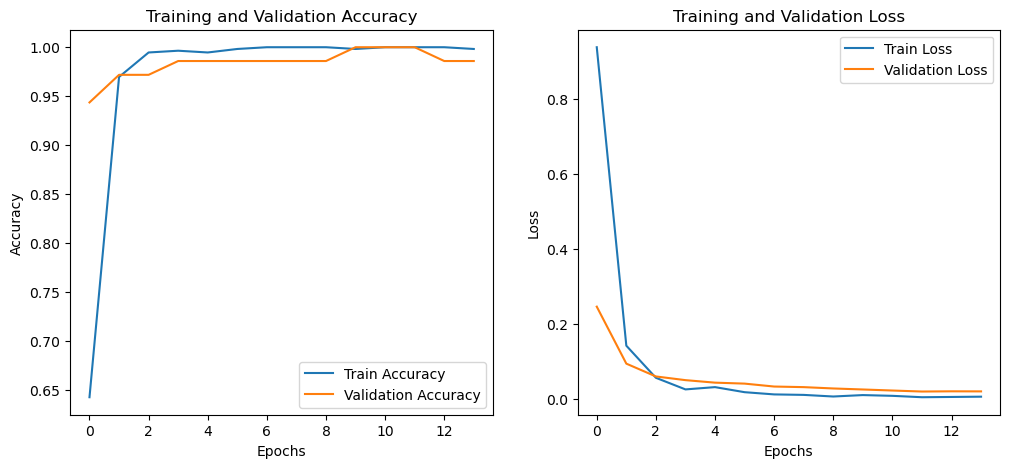

In [54]:
# Evaluate the model

test_loss, test_accuracy = dense_model_effnet_t1.evaluate(output_features_test, y_test, batch_size=32)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot accuracy and loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(effnet_model_t1_history.history['accuracy'], label='Train Accuracy')
plt.plot(effnet_model_t1_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(effnet_model_t1_history.history['loss'], label='Train Loss')
plt.plot(effnet_model_t1_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Comparison of all the models:

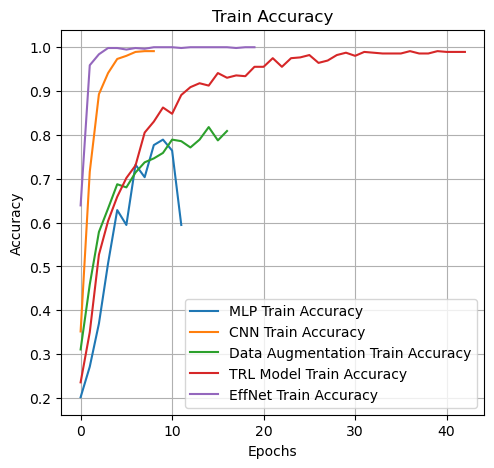

In [57]:
# Plot 1: Train Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='MLP Train Accuracy')
plt.plot(history_cnn.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history_data_aug.history['accuracy'], label='Data Augmentation Train Accuracy')
plt.plot(trlr_model_history.history['accuracy'], label='TRL Model Train Accuracy')
plt.plot(effnet_model_history.history['accuracy'], label='EffNet Train Accuracy')
plt.title('Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

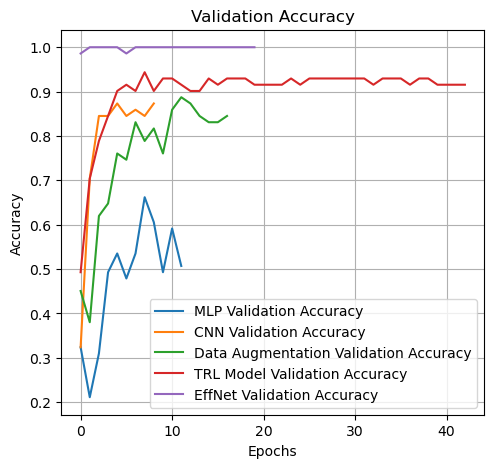

In [58]:
# Plot 2: Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='MLP Validation Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')
plt.plot(history_data_aug.history['val_accuracy'], label='Data Augmentation Validation Accuracy')
plt.plot(trlr_model_history.history['val_accuracy'], label='TRL Model Validation Accuracy')
plt.plot(effnet_model_history.history['val_accuracy'], label='EffNet Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

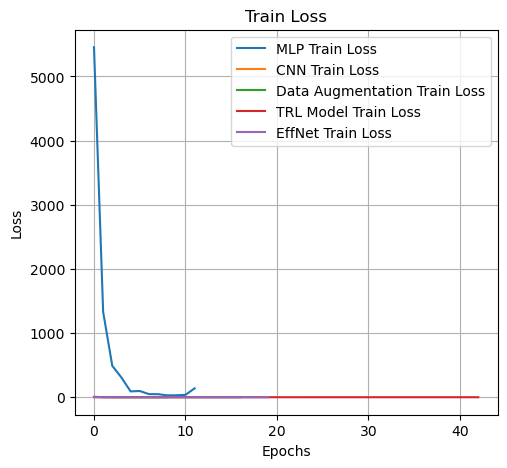

In [59]:
# Plot 3: Train Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='MLP Train Loss')
plt.plot(history_cnn.history['loss'], label='CNN Train Loss')
plt.plot(history_data_aug.history['loss'], label='Data Augmentation Train Loss')
plt.plot(trlr_model_history.history['loss'], label='TRL Model Train Loss')
plt.plot(effnet_model_history.history['loss'], label='EffNet Train Loss')
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

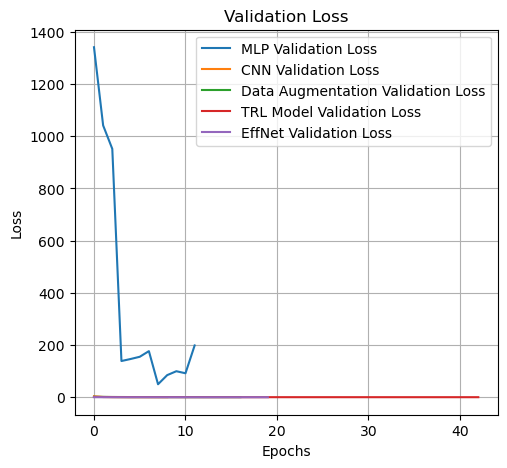

In [63]:
# Plot 4: Validation Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='MLP Validation Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.plot(history_data_aug.history['val_loss'], label='Data Augmentation Validation Loss')
plt.plot(trlr_model_history.history['val_loss'], label='TRL Model Validation Loss')
plt.plot(effnet_model_history.history['val_loss'], label='EffNet Validation Loss')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()
